# ttbaranalysis

Use the configuration widgets below to choose the datasets, year, taggers, thresholds, systematics, and execution mode. The widget state is saved to `.last_config.json`, then converted into the `args` object used by the same analysis flow as `ttbaranalysis.py`.

In [12]:
from coffea import util
from coffea.nanoevents import NanoAODSchema, BaseSchema
import coffea.processor as processor

import itertools
import time
from datetime import date
import json
import os
from types import SimpleNamespace

from dask.distributed import Client, performance_report

import warnings

warnings.filterwarnings("ignore")
import logging
import dask

dask.config.set({"logging.distributed": "error"})

for name in [
    "distributed",
    "distributed.scheduler",
    "distributed.core",
    "distributed.nanny",
    "distributed.worker",
]:
    logging.getLogger(name).setLevel(logging.CRITICAL)

default_datastets = ["data", "TTbar", "QCD"]
default_signals = ["RSGluon", "ZPrime10", "ZPrime30", "ZPrimeDM", "ZPrime1"]

from ttbarprocessor import TTbarResProcessor
from python.functions import printTime, makeSaveDirectories

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# ── Widgets for interactive configuration ─────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display
import json, os

CONFIG_FILE = ".last_config.json"

DEFAULTS = dict(
    dataset=["ZPrimeLocal"],
    signals=False,
    iov="2024",
    era=[],
    pt=[],
    mass="",
    blind=False,
    bkgest=None,
    toptagger="deepak8",
    redirector="rootfiles/",
    ttagWP="medium",
    btagger="deepcsv",
    ht="1400",
    noSyst=False,
    dask=False,
    env="lpc",
    test=False,
    nocluster=False,
)


def load_config():
    if os.path.exists(CONFIG_FILE):
        try:
            with open(CONFIG_FILE) as f:
                return {**DEFAULTS, **json.load(f)}
        except Exception:
            pass
    return dict(DEFAULTS)


def save_config(_=None):
    cfg = dict(
        dataset=list(w_dataset.value),
        signals=w_signals.value,
        iov=w_iov.value,
        era=list(w_era.value),
        pt=list(w_pt.value),
        mass=w_mass.value,
        blind=w_blind.value,
        bkgest=w_bkgest.value,
        toptagger=w_toptagger.value,
        redirector=w_redirector.value,
        ttagWP=w_ttagWP.value,
        btagger=w_btagger.value,
        ht=w_ht.value,
        noSyst=w_noSyst.value,
        dask=w_dask.value,
        env=w_env.value,
        test=w_test.value,
        nocluster=w_nocluster.value,
    )
    with open(CONFIG_FILE, "w") as f:
        json.dump(cfg, f, indent=2)


cfg = load_config()

style = {"description_width": "80px"}
layout = widgets.Layout(width="210px")
layout_wide = widgets.Layout(width="260px")

_dataset_opts = [
    "data",
    "QCD",
    "TTbar",
    "ZPrime1",
    "ZPrime10",
    "ZPrime30",
    "ZPrimeDM",
    "RSGluon",
    "ZPrimeLocal",
]
_era_opts = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
_pt_opts = ["700to1000", "1000toInf"]

# ── Datasets ──────────────────────────────────────────────────────────────────
w_dataset = widgets.SelectMultiple(
    options=_dataset_opts,
    value=tuple(v for v in cfg["dataset"] if v in _dataset_opts),
    description="Dataset",
    style=style,
    layout=widgets.Layout(width="210px", height="150px"),
)
w_signals = widgets.Checkbox(
    value=cfg["signals"], description="Signals only", style=style, layout=layout
)

# ── IOV ───────────────────────────────────────────────────────────────────────
w_iov = widgets.Dropdown(
    options=["2022", "2023", "2024"],
    value=cfg["iov"],
    description="IOV",
    style=style,
    layout=layout,
)

# ── Subsections ───────────────────────────────────────────────────────────────
w_era = widgets.SelectMultiple(
    options=_era_opts,
    value=tuple(v for v in cfg["era"] if v in _era_opts),
    description="Era",
    style=style,
    layout=widgets.Layout(width="210px", height="120px"),
)
w_pt = widgets.SelectMultiple(
    options=_pt_opts,
    value=tuple(v for v in cfg["pt"] if v in _pt_opts),
    description="pT bin",
    style=style,
    layout=widgets.Layout(width="210px", height="55px"),
)
w_mass = widgets.Text(
    value=cfg["mass"],
    placeholder="e.g. 1000,2000",
    description="Mass pts",
    style=style,
    layout=layout,
)

# ── Analysis options ──────────────────────────────────────────────────────────
w_blind = widgets.Checkbox(
    value=cfg["blind"], description="Blind", style=style, layout=layout
)
w_bkgest = widgets.Dropdown(
    options=[("None", None), "2dalphabet", "mistag"],
    value=cfg["bkgest"],
    description="Bkg est",
    style=style,
    layout=layout,
)
w_toptagger = widgets.Dropdown(
    options=["deepak8", "cmsv2"],
    value=cfg["toptagger"],
    description="Top tagger",
    style=style,
    layout=layout,
)
w_redirector = widgets.Dropdown(
    options=[
        ("Local (rootfiles/)", "rootfiles/"),
        ("FNAL XRootD (root://cmsxrootd.fnal.gov/)", "root://cmsxrootd.fnal.gov/"),
    ],
    value=cfg["redirector"],
    description="Redirector",
    style=style,
    layout=layout_wide,
)
w_ttagWP = widgets.Dropdown(
    options=["loose", "medium", "tight"],
    value=cfg["ttagWP"],
    description="ttag WP",
    style=style,
    layout=layout,
)
w_btagger = widgets.Dropdown(
    options=["deepcsv", "csvv2"],
    value=cfg["btagger"],
    description="B tagger",
    style=style,
    layout=layout,
)
w_ht = widgets.Dropdown(
    options=["1400", "950"],
    value=cfg["ht"],
    description="HT cut",
    style=style,
    layout=layout,
)
w_noSyst = widgets.Checkbox(
    value=cfg["noSyst"], description="No syst", style=style, layout=layout
)

# ── Run options ───────────────────────────────────────────────────────────────
w_dask = widgets.Checkbox(
    value=cfg["dask"], description="Dask", style=style, layout=layout
)
w_env = widgets.Dropdown(
    options=["casa", "lpc", "winterfell", "local", "C", "L", "W"],
    value=cfg["env"],
    description="Env",
    style=style,
    layout=layout,
)
w_test = widgets.Checkbox(
    value=cfg["test"], description="Test", style=style, layout=layout
)
w_nocluster = widgets.Checkbox(
    value=cfg["nocluster"], description="No cluster", style=style, layout=layout
)

# ── Auto-save on every change ─────────────────────────────────────────────────
for _w in [
    w_dataset,
    w_signals,
    w_iov,
    w_era,
    w_pt,
    w_mass,
    w_blind,
    w_bkgest,
    w_toptagger,
    w_redirector,
    w_ttagWP,
    w_btagger,
    w_ht,
    w_noSyst,
    w_dask,
    w_env,
    w_test,
    w_nocluster,
]:
    _w.observe(save_config, names="value")


# ── Reset to defaults button ──────────────────────────────────────────────────
def reset_to_defaults(_):
    w_dataset.value = tuple(DEFAULTS["dataset"])
    w_signals.value = DEFAULTS["signals"]
    w_iov.value = DEFAULTS["iov"]
    w_era.value = tuple(DEFAULTS["era"])
    w_pt.value = tuple(DEFAULTS["pt"])
    w_mass.value = DEFAULTS["mass"]
    w_blind.value = DEFAULTS["blind"]
    w_bkgest.value = DEFAULTS["bkgest"]
    w_toptagger.value = DEFAULTS["toptagger"]
    w_redirector.value = DEFAULTS["redirector"]
    w_ttagWP.value = DEFAULTS["ttagWP"]
    w_btagger.value = DEFAULTS["btagger"]
    w_ht.value = DEFAULTS["ht"]
    w_noSyst.value = DEFAULTS["noSyst"]
    w_dask.value = DEFAULTS["dask"]
    w_env.value = DEFAULTS["env"]
    w_test.value = DEFAULTS["test"]
    w_nocluster.value = DEFAULTS["nocluster"]


btn_reset = widgets.Button(
    description="↺ Reset to Defaults",
    button_style="warning",
    layout=widgets.Layout(width="160px", margin="8px 0 0 0"),
)
btn_reset.on_click(reset_to_defaults)

# ── Display ───────────────────────────────────────────────────────────────────
hdr = lambda t: widgets.HTML(f'<b style="font-size:0.9em">{t}</b>')

col1 = widgets.VBox(
    [hdr("Datasets"), w_dataset, w_signals, hdr("IOV"), w_iov],
    layout=widgets.Layout(margin="0 8px 0 0"),
)
col2 = widgets.VBox(
    [hdr("Subsections"), w_era, w_pt, w_mass], layout=widgets.Layout(margin="0 8px 0 0")
)
col3 = widgets.VBox(
    [
        hdr("Analysis Options"),
        w_blind,
        w_bkgest,
        w_toptagger,
        w_redirector,
        w_ttagWP,
        w_btagger,
        w_ht,
        w_noSyst,
    ],
    layout=widgets.Layout(margin="0 8px 0 0"),
)
col4 = widgets.VBox([hdr("Run Options"), w_dask, w_env, w_test, w_nocluster, btn_reset])

display(widgets.HBox([col1, col2, col3, col4]))
_loaded = (
    "restored from last session" if os.path.exists(CONFIG_FILE) else "using defaults"
)
display(
    widgets.HTML(
        f'<i style="font-size:0.82em; color:gray">Config {_loaded} · auto-saved to <code>.last_config.json</code> on each change.</i>'
    )
)
print("Adjust widgets above, then run the next cell to apply settings.")

HTML(value='<i style="font-size:0.82em; color:gray">Config restored from last session · auto-saved to <code>.l…

Adjust widgets above, then run the next cell to apply settings.


In [ ]:
from types import SimpleNamespace


def build_args():
    selected_datasets = list(w_dataset.value)
    if w_signals.value:
        selected_datasets = list(default_signals)

    mass_list = [m.strip() for m in w_mass.value.split(",") if m.strip()]

    return SimpleNamespace(
        dataset=selected_datasets,
        iov=w_iov.value,
        signals=w_signals.value,
        era=list(w_era.value),
        pt=list(w_pt.value),
        mass=mass_list,
        blind=w_blind.value,
        bkgest=w_bkgest.value,
        toptagger=w_toptagger.value,
        redirector=w_redirector.value,
        ttagWP=w_ttagWP.value,
        btagger=w_btagger.value,
        ht=w_ht.value,
        noSyst=w_noSyst.value,
        dask=w_dask.value,
        env=w_env.value,
        test=w_test.value,
        nocluster=w_nocluster.value,
    )


args = build_args()
print("------args------")
for argname, value in vars(args).items():
    print(argname, "=", value)
print("----------------")

------args------
dataset = ['ZPrimeLocal']
iov = 2024
signals = False
era = []
pt = []
mass = []
blind = False
bkgest = None
toptagger = deepak8
redirector = rootfiles/
ttagWP = medium
btagger = deepcsv
ht = 1400
noSyst = False
dask = False
env = local
test = True
nocluster = True
----------------


In [ ]:
def run_analysis(args):
    tic = time.time()

    savedir = f"outputs/dy/"

    if args.dask and (args.env == "lpc" or args.env == "L"):
        from lpcjobqueue import LPCCondorCluster

    samples = args.dataset
    IOV = args.iov
    useDeepAK8 = True if (args.toptagger == "deepak8") else False
    useDeepCSV = True if (args.btagger == "deepcsv") else False
    htCut = 1400.0 if (args.ht == "1400") else 950.0
    dask_memory = "5GB"
    chunksize_dask = 100000
    chunksize_futures = 200000
    maxchunks = 10 if args.test else None

    systematics = [
        "nominal",
        "jes",
        "jer",
        "pileup",
        "pdf",
        "q2",
        "ttag_pt1",
        #'ttag_pt2',
        #'ttag_pt3'
    ]

    if ("2016" in IOV) or ("2017" in IOV):
        systematics.append("prefiring")

    if args.bkgest == "2dalphabet":
        systematics.append("transferFunction")

    # systematics = ['nominal', 'jes', 'pileup']
    ttagcats = ["at", "2t"]
    ycats = ["cen", "fwd"]

    anacats = [t + y for t, y in itertools.product(ttagcats, ycats)]
    label_map = {i: label for i, label in enumerate(anacats)}

    with open("out.log", "w") as f:
        print("\n" + date.today().isoformat(), file=f)
        # print('\n------args------', file=f)
        # for argname, value in vars(args).items():
        #     print(argname, '=', value, file=f)
        # print('----------------\n', file=f)
        print("categories =", label_map, file=f)
        print("\n", file=f)
        if not args.noSyst:
            print("systematics =", systematics, file=f)

    print("\n------args------")
    for argname, value in vars(args).items():
        print(argname, "=", value)
    if not args.noSyst:
        print("systematics =", systematics)
    print("----------------\n")

    if args.env == "casa" or args.env == "C":
        redirector = "root://xcache/"
    elif args.env == "winterfell" or args.env == "W":
        redirector = "/mnt/data/cms/"
    else:
        redirector = args.redirector

    jsonfiles = {
        "data": "data/nanoAOD/data.json",
        "QCD": "data/nanoAOD/QCD.json",
        "TTbar": "data/nanoAOD/TTbar.json",
        "ZPrime1": "data/nanoAOD/ZPrime1.json",
        "ZPrime10": "data/nanoAOD/ZPrime10.json",
        "ZPrime30": "data/nanoAOD/ZPrime30.json",
        "ZPrimeDM": "data/nanoAOD/ZPrimeDM.json",
        "RSGluon": "data/nanoAOD/RSGluon.json",
        "ZPrimeLocal": "data/nanoAOD/local.json",
    }

    repo_root = os.path.abspath(os.getcwd())
    upload_to_dask = ["data", "python", "ttbarprocessor.py"]

    if not os.path.exists(savedir):
        os.makedirs(savedir)
        os.makedirs(savedir + "logs/")
        os.makedirs(savedir + "scale/")
        os.makedirs(savedir + "twodalphabet/")
        os.popen(
            "cp ttbarprocessor.py "
            + savedir
            + "logs/ttbarprocessor_"
            + date.today().isoformat().replace("-", "")
            + ".py"
        )
        os.popen("cat out.log >> " + savedir + "logs/ttbarprocessor_diff.txt")
    else:
        for f in os.listdir(savedir + "logs/"):
            if "ttbarprocessor" in f and "py" in f:
                os.popen("cat out.log >> " + savedir + "logs/ttbarprocessor_diff.txt")
                print(
                    "diff ttbarprocessor.py "
                    + savedir
                    + "logs/"
                    + f
                    + " >> "
                    + savedir
                    + "logs/ttbarprocessor_diff.txt"
                )
                os.popen(
                    "diff ttbarprocessor.py "
                    + savedir
                    + "logs/"
                    + f
                    + " >> "
                    + savedir
                    + "logs/ttbarprocessor_diff.txt"
                )

        if not os.path.exists(savedir):
            os.makedirs(savedir + "scale/")
        if not os.path.exists(savedir + "twodalphabet/"):
            os.makedirs(savedir + "twodalphabet/")

    makeSaveDirectories(coffea_dir=savedir)

    metrics = None

    for sample in samples:
        skipbadfiles = False
        inputfile = jsonfiles[sample]

        with open(inputfile) as json_file:
            subsections = args.era + args.mass + args.pt
            data = json.load(json_file)

            filedict = {}

            try:
                data[IOV].keys()

                if len(subsections) > 0:
                    for s in subsections:
                        if s in data[IOV].keys():
                            filedict[s] = data[IOV][s]
                        else:
                            print(f"{s} not in {sample} {IOV}")
                else:
                    filedict = data[IOV]
            except Exception:
                filedict[""] = data[IOV]

            for subsection, files in filedict.items():
                files = [redirector + f for f in files]
                if args.test:
                    files = [files[int(len(files) / 2)]]
                    nworkers = 1
                    maxchunks = 1
                else:
                    nworkers = 4

                fileset = {sample: files}

                print(files[0])

                subString = subsection.replace("700to", "_700to").replace(
                    "1000to", "_1000to"
                )
                if args.bkgest:
                    subString += "_bkgest"

                if (args.toptagger == "cmsv2") and (args.btagger == "csvv2"):
                    savedir = "outputs/oldanalysis/"

                savefilename = f"{savedir}{sample}_{IOV}{subString}.coffea"
                if "RSGluon" in sample:
                    subString = subString.replace(subsection, "")
                    savefilename = (
                        f"{savedir}{sample}{subsection}_{IOV}{subString}.coffea"
                    )
                elif "ZPrime" in sample:
                    subString = subString.replace(subsection, "")
                    savefilename = f'{savedir}ZPrime{subsection}_{sample.replace("ZPrime", "")}_{IOV}{subString}.coffea'
                print(f"running {IOV} {sample} {subsection}")

                if args.toptagger == "cmsv2":
                    savefilename = savefilename.replace(".coffea", "_cmsv2.coffea")
                if args.btagger == "csvv2":
                    savefilename = savefilename.replace(".coffea", "_csvv2.coffea")
                if args.ht == "950":
                    savefilename = savefilename.replace(".coffea", "_ht950.coffea")
                if args.blind:
                    savefilename = savefilename.replace(".coffea", "_blind.coffea")
                if args.noSyst:
                    savefilename = savefilename.replace(".coffea", "_noSyst.coffea")
                if args.test:
                    savefilename = savefilename.replace(".coffea", "_test.coffea")

                if not args.dask:  # using local futures
                    # print(fileset)
                    runner = processor.Runner(
                        executor=processor.FuturesExecutor(
                            workers=nworkers,
                        ),
                        schema=NanoAODSchema,
                        chunksize=chunksize_futures,
                        maxchunks=maxchunks,
                        skipbadfiles=skipbadfiles,
                        xrootdtimeout=500,
                        savemetrics=True,
                    )

                    output, metrics = runner(
                        fileset,
                        treename="Events",
                        processor_instance=TTbarResProcessor(
                            iov=IOV,
                            bkgEst=args.bkgest,
                            noSyst=args.noSyst,
                            deepAK8Cut=args.ttagWP,
                            useDeepAK8=useDeepAK8,
                            useDeepCSV=useDeepCSV,
                            htCut=htCut,
                            anacats=anacats,
                            systematics=systematics,
                            blinding=args.blind,
                            debug=True,
                        ),
                    )
                else:
                    if args.dask and (args.env == "lpc" or args.env == "L"):
                        if args.nocluster:
                            cluster = None
                        else:
                            cluster = LPCCondorCluster(
                                memory=dask_memory,
                                transfer_input_files=upload_to_dask,
                                scheduler_options={"dashboard_address": ":8787"},
                            )
                            cluster.adapt(minimum=1, maximum=100)
                    elif args.dask and (args.env == "casa" or args.env == "C"):
                        if args.nocluster:
                            cluster = None
                        else:
                            from coffea_casa import CoffeaCasaCluster

                            cluster = CoffeaCasaCluster(memory=dask_memory)
                            cluster.adapt(minimum=4, maximum=400)
                            client = Client(cluster)
                            from distributed.diagnostics.plugin import UploadDirectory

                            client.register_worker_plugin(
                                UploadDirectory(
                                    os.path.join(repo_root, "data"),
                                    restart=True,
                                    update_path=True,
                                ),
                                nanny=True,
                            )
                            from distributed.diagnostics.plugin import UploadDirectory

                            client.register_worker_plugin(
                                UploadDirectory(
                                    os.path.join(repo_root, "python"),
                                    restart=True,
                                    update_path=True,
                                ),
                                nanny=True,
                            )

                            client.upload_file(
                                os.path.join(repo_root, "ttbarprocessor.py")
                            )

                    else:
                        cluster = dask.distributed.LocalCluster(
                            n_workers=nworkers,
                            threads_per_worker=1,
                            scheduler_port=0,
                            dashboard_address=":8787",
                        )

                    upload_to_dask = [
                        "data",
                        "python",
                        "ttbarprocessor.py",
                    ]

                    with Client(cluster) as client:
                        run_instance = processor.Runner(
                            metadata_cache={},
                            executor=processor.DaskExecutor(client=client, retries=2),
                            schema=NanoAODSchema,
                            savemetrics=True,
                            skipbadfiles=skipbadfiles,
                            chunksize=chunksize_dask,
                            maxchunks=maxchunks,
                        )

                        # if args.nocluster:
                        #     worker_toc = time.time()
                        #     print('Waiting for 4 workers...')
                        #     client.wait_for_workers(4)
                        #     worker_tic = time.time()
                        # else:
                        #     worker_toc = time.time()
                        #     print('Waiting for at least one worker...')
                        #     client.wait_for_workers(1)
                        #     worker_tic = time.time()

                        # print(f'time to wait for worker = {int(worker_tic - worker_toc)}s')

                        output, metrics = run_instance(
                            fileset,
                            treename="Events",
                            processor_instance=TTbarResProcessor(
                                iov=IOV,
                                bkgEst=args.bkgest,
                                noSyst=args.noSyst,
                                deepAK8Cut=args.ttagWP,
                                useDeepAK8=useDeepAK8,
                                useDeepCSV=useDeepCSV,
                                htCut=htCut,
                                anacats=anacats,
                                systematics=systematics,
                                blinding=args.blind,
                            ),
                        )

                        client.shutdown()
                        del cluster

                output["analysisCategories"] = label_map
                util.save(output, savefilename)
                print("saving", savefilename)

    elapsed = time.time() - tic
    printTime(elapsed)
    if metrics is not None:
        print(f"Events/s: {metrics['entries'] / elapsed:.0f}")

    return {"elapsed": elapsed, "metrics": metrics, "output": output}

In [6]:
args = build_args()
run_summary = run_analysis(args)


------args------
dataset = ['ZPrimeLocal']
iov = 2024
signals = False
era = []
pt = []
mass = []
blind = False
bkgest = None
toptagger = deepak8
redirector = rootfiles/
ttagWP = medium
btagger = deepcsv
ht = 1400
noSyst = False
dask = False
env = local
test = True
nocluster = True
systematics = ['nominal', 'jes', 'jer', 'pileup', 'pdf', 'q2', 'ttag_pt1']
----------------

diff ttbarprocessor.py outputs/dy/logs/ttbarprocessor_20260311.py >> outputs/dy/logs/ttbarprocessor_diff.txt
coffea dir outputs/dy/
plots dir images/dy/
rootfiles/store/mc/712cf530-ef49-4056-87c6-b7527903ba80.root
running 2024 ZPrimeLocal 4000


Output()

Output()

/home/aritra/.pyenv/versions/coffea_latest/lib/python3.11/site-packages/coffea/lookup_tools/txt_converters.py:188: UserWarning: binning for file for Summer24Prompt24_V2_MC_L2Relative_AK8PFPuppi is malformed in variable JetPhi
  warnings.warn(


[DEBUG] start processor: correction=nominal, memory=711.35 MB
[CUTFLOW] after trigger (cumulative): 38310
[CUTFLOW] after htCut (cumulative): 35848
[CUTFLOW] after metfilter (cumulative): 35381
[CUTFLOW] after jetkincut (cumulative): 35368
[CUTFLOW] after twoFatJets (cumulative): 34193
[CUTFLOW] after all preselection (eventCut): 34193


...

[CUTFLOW] antitag: 1811, ttag_s0: 31502, ttag_s1: 11050, 2tag: 11050
[CUTFLOW] category 'atcen': 866
[CUTFLOW] category 'atfwd': 945
[CUTFLOW] category '2tcen': 4465
[CUTFLOW] category '2tfwd': 6585


/home/aritra/.pyenv/versions/coffea_latest/lib/python3.11/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[DEBUG] start processor: correction=jesUp, memory=1.63 GB
[DEBUG] start processor: correction=jesDown, memory=1.63 GB


[DEBUG] start processor: correction=jerUp, memory=1.63 GB
[DEBUG] start processor: correction=jerDown, memory=1.63 GB


saving outputs/dy/ZPrime4000_Local_2024_test.coffea
Elapsed Time: 0 h 0 min 40 sec
Events/s: 1095


In [ ]:
output = run_summary["output"]
print(output["cutflow"])
for key in output:
    print(key)

defaultdict_accumulator(<class 'int'>, {'all events 1': 44000, 'all events': 44000, 'sumw': np.float32(44000.0), 'sumw2': np.float32(44000.0), 'trigger': 38310, 'htCut': 35848, 'metfilter': 35381, 'jetkincut': 35368, 'twoFatJets': 34193, 'after_eventCut': 34193, 'after_ttbarcandCuts': 33154, 'atcen': 866, 'atfwd': 945, '2tcen': 4465, '2tfwd': 6585})
ttbarmass
mtt_unwgt
mtt_vs_mt
numerator
denominator
jetmass
jetmsd
jetdy
jetmass1
jetmsd1
dR_min_jet2
jet0_pt
jet0_eta
jet0_phi
jet0_rapidity
jet1_pt
jet1_eta
jet1_phi
jet1_rapidity
gen_mt
gen_mttbar
jet0_gen_dr
jet1_gen_dr
jet_mass_resolution
gen_jetmsd_reco_jetmsd
ht
cutflow
weights
systematics
event_list
truthstudy
analysisCategories


In [ ]:
output["cutflow"]

defaultdict_accumulator(int,
                        {'all events 1': 44000,
                         'all events': 44000,
                         'sumw': np.float32(44000.0),
                         'sumw2': np.float32(44000.0),
                         'trigger': 38310,
                         'htCut': 35848,
                         'metfilter': 35381,
                         'jetkincut': 35368,
                         'twoFatJets': 34193,
                         'after_eventCut': 34193,
                         'after_ttbarcandCuts': 33154,
                         'atcen': 866,
                         'atfwd': 945,
                         '2tcen': 4465,
                         '2tfwd': 6585})

In [ ]:
output["ttbarmass"]

Hist(
  StrCategory(['nominal', 'jesDown', 'jesUp', 'jerDown', 'jerUp', 'pileupDown', 'pileupUp', 'pdfDown', 'pdfUp', 'q2Down', 'q2Up', 'ttag_pt1Down', 'ttag_pt1Up'], name='systematic'),
  IntCategory([0, 1, 2, 3], name='anacat', label='Analysis Category'),
  Regular(92, 800, 10000, name='ttbarmass', label='$m_{t\\bar{t}}$ [GeV]'),
  storage=Weight()) # Sum: WeightedSum(value=213097, variance=298607) (WeightedSum(value=278737, variance=389570) with flow)

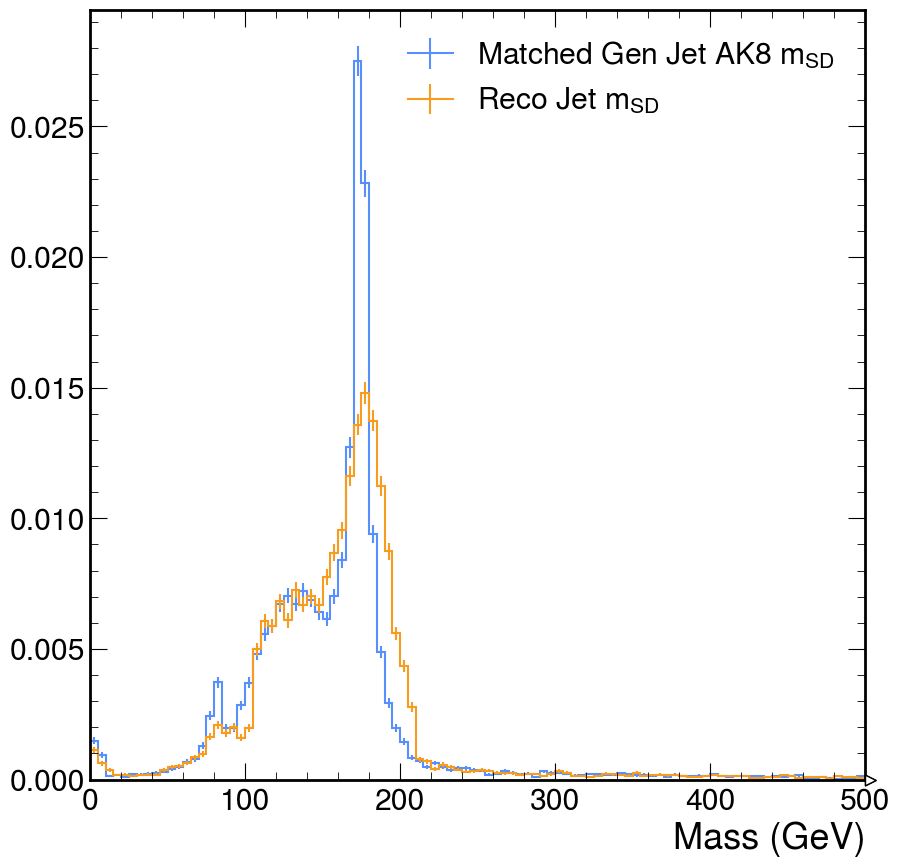

In [ ]:
import matplotlib.pyplot as plt

output["gen_jetmsd_reco_jetmsd"].project("genjetmass").plot(
    label=r"Matched Gen Jet AK8 $m_{SD}$", density=True
)
output["gen_jetmsd_reco_jetmsd"].project("jetmsd").plot(
    label=r"Reco Jet $m_{SD}$", density=True
)
plt.xlabel("Mass (GeV)")
plt.xlim(0, 500)
plt.legend()

(Experiment Label: Text(0.0, 1.0, 'CMS'),
 Experiment Text: Text(0.14586021505376343, 1.0129870129870129, 'Simulation'),
 Luminosity Text: Text(1.0, 1.0, "Z' 4000 GeV"),
 None)

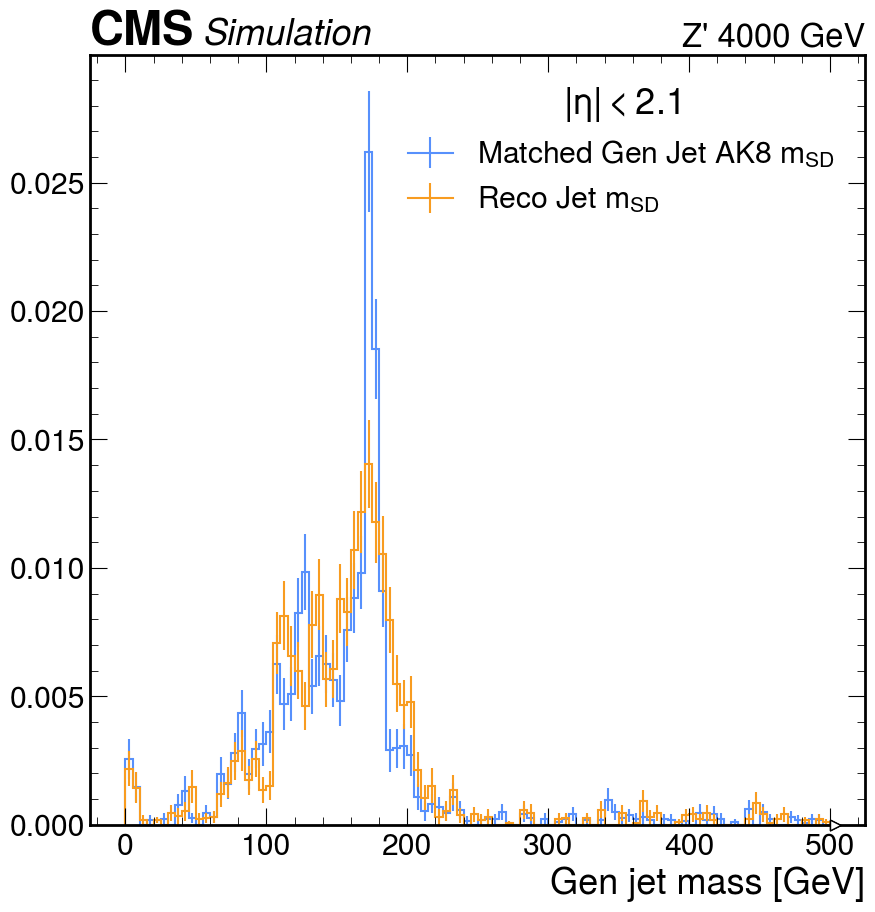

In [ ]:
import mplhep as hep

output["gen_jetmsd_reco_jetmsd"]["nominal", 0, ...].project("genjetmass").plot(
    label=r"Matched Gen Jet AK8 $m_{SD}$", density=True
)
output["gen_jetmsd_reco_jetmsd"]["nominal", 0, ...].project("jetmsd").plot(
    label=r"Reco Jet $m_{SD}$", density=True
)
plt.legend(title=r"$|\eta| < 2.1$")
hep.cms.label(rlabel="Z' 4000 GeV")

(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation'),
 supptext: Custom Text(1.012, 1, ''))

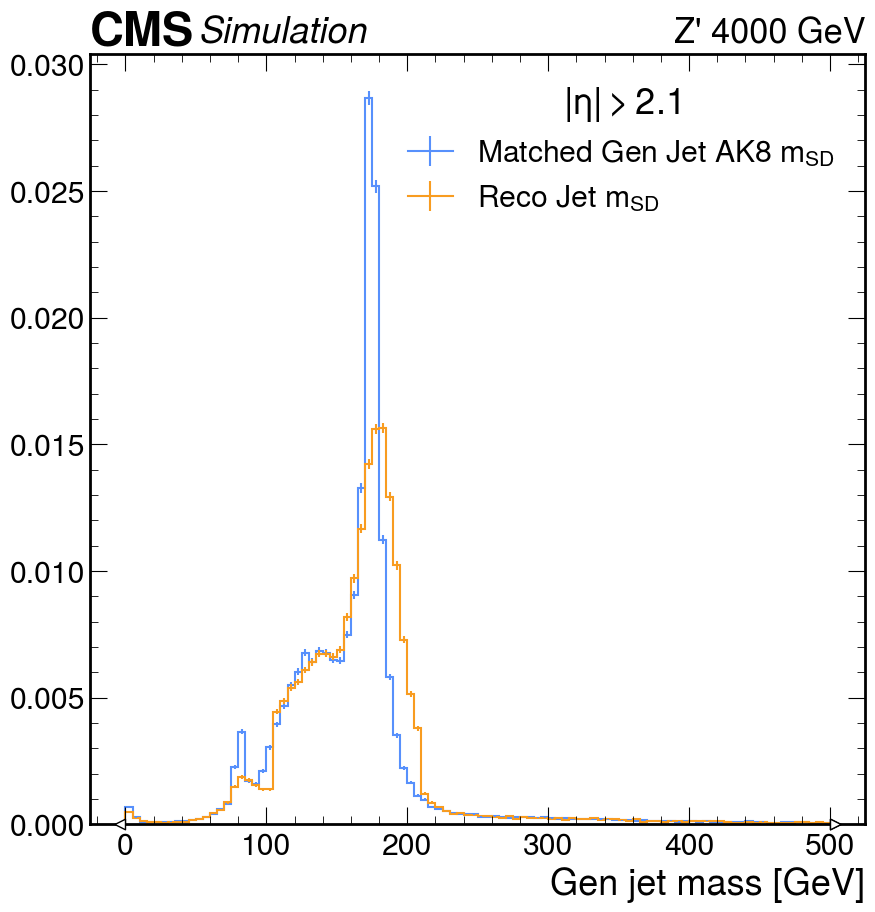

In [ ]:
output["gen_jetmsd_reco_jetmsd"]["nominal", 1, ...].project("genjetmass").plot(
    label=r"Matched Gen Jet AK8 $m_{SD}$", density=True
)
output["gen_jetmsd_reco_jetmsd"]["nominal", 1, ...].project("jetmsd").plot(
    label=r"Reco Jet $m_{SD}$", density=True
)
plt.legend(title=r"$|\eta| > 2.1$")
hep.cms.label(rlabel="Z' 4000 GeV")

(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation'),
 supptext: Custom Text(1.012, 1, ''))

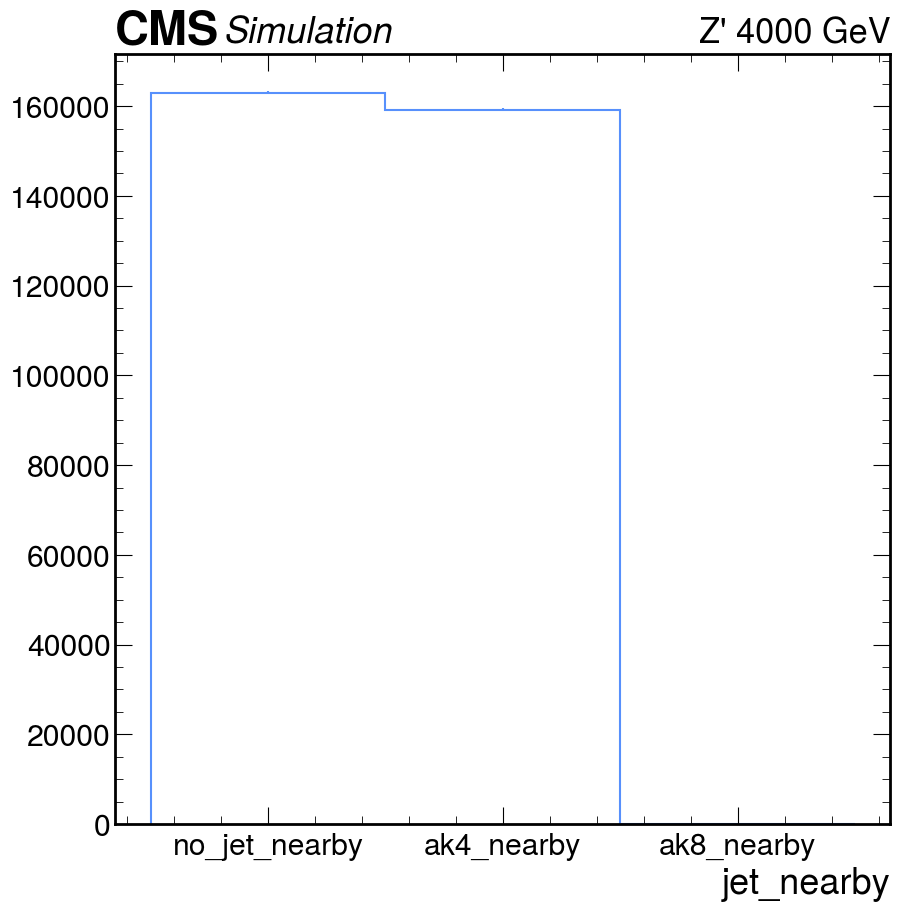

In [ ]:
output["gen_jetmsd_reco_jetmsd"]["nominal", ...].project("jet_nearby").plot()
# plt.legend(title = r"$|\eta| > 2.1$")
hep.cms.label(rlabel="Z' 4000 GeV")

(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation'),
 supptext: Custom Text(1.012, 1, ''))

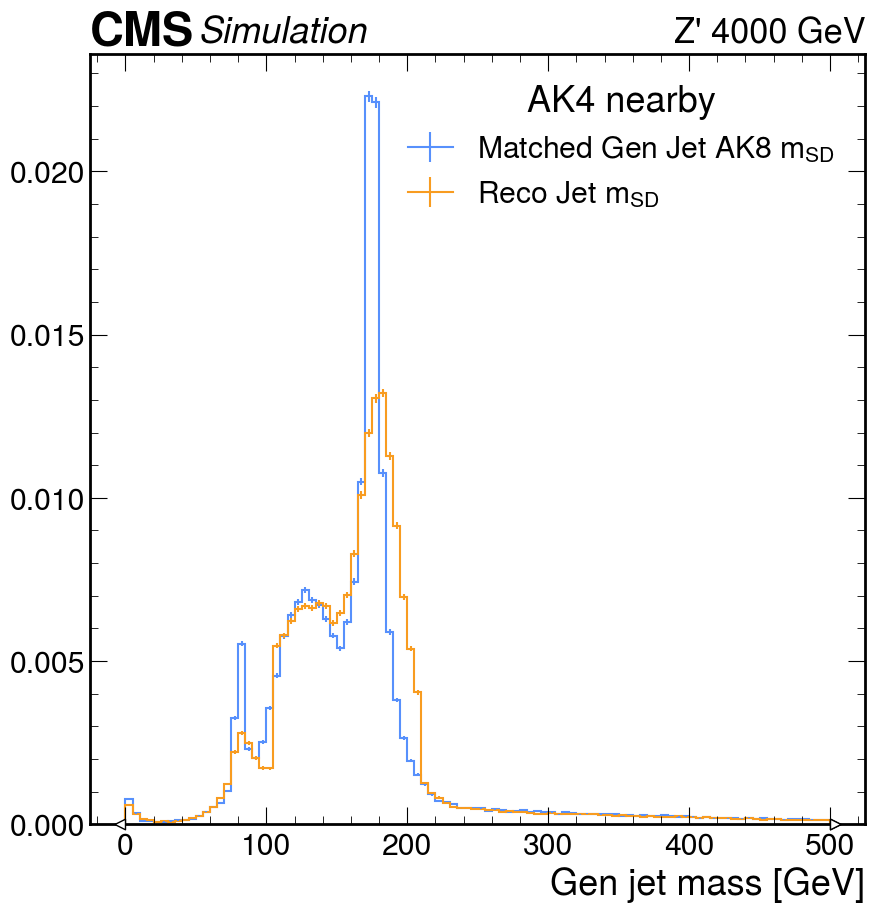

In [ ]:
output["gen_jetmsd_reco_jetmsd"]["nominal", :, :, "ak4_nearby", ...].project(
    "genjetmass"
).plot(label=r"Matched Gen Jet AK8 $m_{SD}$", density=True)
output["gen_jetmsd_reco_jetmsd"]["nominal", :, :, "ak4_nearby", ...].project(
    "jetmsd"
).plot(label=r"Reco Jet $m_{SD}$", density=True)
plt.legend(title=r"AK4 nearby")
hep.cms.label(rlabel="Z' 4000 GeV")

(exptext: Custom Text(0.0, 1, 'CMS'),
 expsuffix: Custom Text(0.0, 1.005, 'Simulation'),
 supptext: Custom Text(1.012, 1, ''))

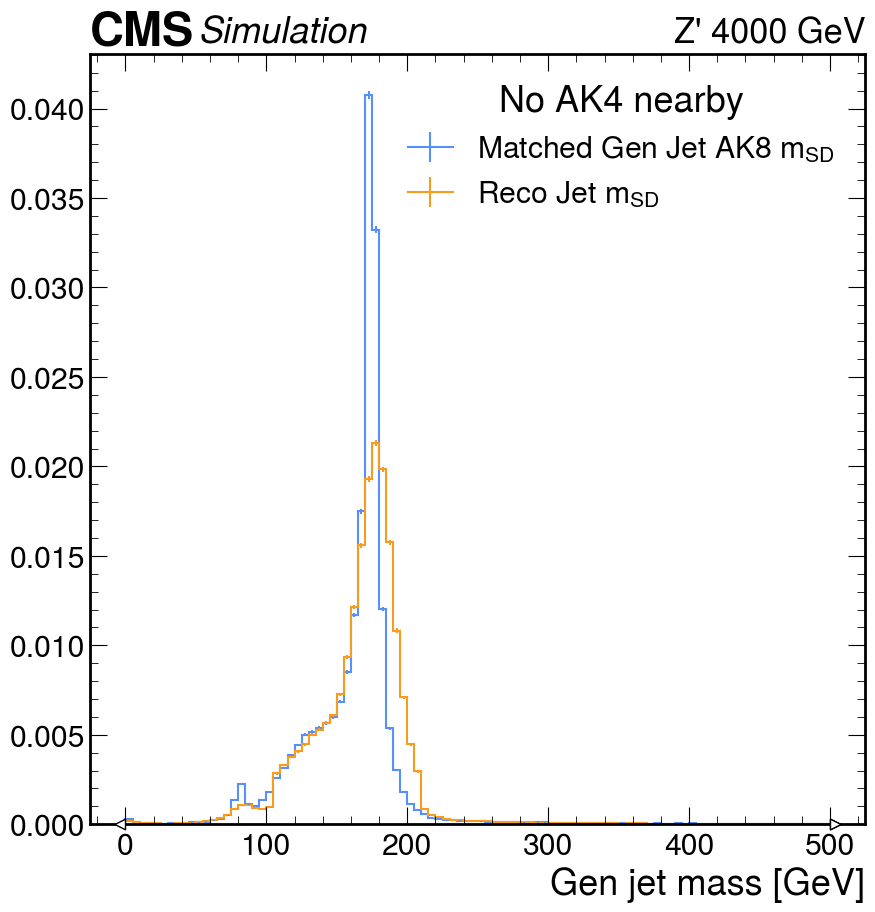

In [ ]:
output["gen_jetmsd_reco_jetmsd"]["nominal", :, :, "no_jet_nearby", ...].project(
    "genjetmass"
).plot(label=r"Matched Gen Jet AK8 $m_{SD}$", density=True)
output["gen_jetmsd_reco_jetmsd"]["nominal", :, :, "no_jet_nearby", ...].project(
    "jetmsd"
).plot(label=r"Reco Jet $m_{SD}$", density=True)
plt.legend(title=r"No AK4 nearby")
hep.cms.label(rlabel="Z' 4000 GeV")

In [18]:
import coffea
from coffea.dataset_tools import dataset_query

In [19]:
from coffea.dataset_tools.rucio_utils import get_dataset_files_replicas

In [20]:
outfiles, outsites, sites_counts = get_dataset_files_replicas(
    dataset="/DYJetsToLL_M-50_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM",
)

Loading SITECONF info
Wrong Rucio configuration, impossible to create client



Couldn't find a valid proxy.



Exception: VOMS proxy expirend or non-existing: please run `voms-proxy-init -voms cms -rfc --valid 168:0`